# LINEAR REGGRESSION AND HOUSING DATA ANALYSIS

# The business problem.


The **Ames Housing** data set, a structured CSV contains a mixture of nominal (neighborhoods), ordinal (quality ratings), continuous
(sales price, square footage) and discrete (count of rooms) variables.

 Our target is 'SalePrice' = 'y' and features are denoted by 'X.'  SalePrice is a continous number in the data so we selected regression modeling.  The goal - accurately predict the sales price, from features - identifying what features relate to y variable.


Import libraries.  Data collection/sources: The AMES Housing Data and Housing Data Document (SIZE: 2930 observations, 82 variables)

In [ ]:
import pandas as pd
import numpy as np


from scipy import stats
from rich import print

from google.colab import userdata
import os


In [ ]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'
housing  = pd.read_csv(url)
housing.shape  # total rows = 2637 and total columns = 81

(2637, 81)

Took the Housing document .pdf and created a queryable, color coded data dictionary as pandas DataFrame this will make it easier to encode the ordinal and nominal data if needed. The code was AI GENERATED

In [ ]:
# Housing Data Dictionary — built from the official documentation PDF
data_dict_rows = [
    ('PID', 'Nominal', 'Parcel identification number'),
    ('MS SubClass', 'Nominal', 'Type of dwelling involved in the sale'),
    ('MS Zoning', 'Nominal', 'General zoning classification of the sale'),
    ('Lot Frontage', 'Continuous', 'Linear feet of street connected to property'),
    ('Lot Area', 'Continuous', 'Lot size in square feet'),
    ('Street', 'Nominal', 'Type of road access to property'),
    ('Alley', 'Nominal', 'Type of alley access (NA = No alley access)'),
    ('Lot Shape', 'Ordinal', 'General shape of property'),
    ('Land Contour', 'Nominal', 'Flatness of the property'),
    ('Utilities', 'Ordinal', 'Type of utilities available'),
    ('Lot Config', 'Nominal', 'Lot configuration'),
    ('Land Slope', 'Ordinal', 'Slope of property'),
    ('Neighborhood', 'Nominal', 'Physical locations within Ames city limits'),
    ('Condition 1', 'Nominal', 'Proximity to various conditions'),
    ('Condition 2', 'Nominal', 'Proximity to various conditions (if more than one)'),
    ('Bldg Type', 'Nominal', 'Type of dwelling'),
    ('House Style', 'Nominal', 'Style of dwelling'),
    ('Overall Qual', 'Ordinal', 'Rates overall material and finish (1-10)'),
    ('Overall Cond', 'Ordinal', 'Rates overall condition of the house (1-10)'),
    ('Year Built', 'Discrete', 'Original construction date'),
    ('Year Remod/Add', 'Discrete', 'Remodel date (= construction date if no remodel)'),
    ('Roof Style', 'Nominal', 'Type of roof'),
    ('Roof Matl', 'Nominal', 'Roof material'),
    ('Exterior 1st', 'Nominal', 'Exterior covering on house'),
    ('Exterior 2nd', 'Nominal', 'Exterior covering (if more than one material)'),
    ('Mas Vnr Type', 'Nominal', 'Masonry veneer type'),
    ('Mas Vnr Area', 'Continuous', 'Masonry veneer area in square feet'),
    ('Exter Qual', 'Ordinal', 'Quality of exterior material'),
    ('Exter Cond', 'Ordinal', 'Present condition of exterior material'),
    ('Foundation', 'Nominal', 'Type of foundation'),
    ('Bsmt Qual', 'Ordinal', 'Height of basement (NA = No Basement)'),
    ('Bsmt Cond', 'Ordinal', 'General condition of basement (NA = No Basement)'),
    ('Bsmt Exposure', 'Ordinal', 'Walkout or garden level walls (NA = No Basement)'),
    ('BsmtFin Type 1', 'Ordinal', 'Rating of basement finished area (NA = No Basement)'),
    ('BsmtFin SF 1', 'Continuous', 'Type 1 finished square feet'),
    ('BsmtFin Type 2', 'Ordinal', 'Rating of basement finished area (multi-types)'),
    ('BsmtFin SF 2', 'Continuous', 'Type 2 finished square feet'),
    ('Bsmt Unf SF', 'Continuous', 'Unfinished square feet of basement area'),
    ('Total Bsmt SF', 'Continuous', 'Total square feet of basement area'),
    ('Heating', 'Nominal', 'Type of heating'),
    ('Heating QC', 'Ordinal', 'Heating quality and condition'),
    ('Central Air', 'Nominal', 'Central air conditioning (Y/N)'),
    ('Electrical', 'Ordinal', 'Electrical system'),
    ('1st Flr SF', 'Continuous', 'First floor square feet'),
    ('2nd Flr SF', 'Continuous', 'Second floor square feet'),
    ('Low Qual Fin SF', 'Continuous', 'Low quality finished square feet (all floors)'),
    ('Gr Liv Area', 'Continuous', 'Above grade (ground) living area square feet'),
    ('Bsmt Full Bath', 'Discrete', 'Basement full bathrooms'),
    ('Bsmt Half Bath', 'Discrete', 'Basement half bathrooms'),
    ('Full Bath', 'Discrete', 'Full bathrooms above grade'),
    ('Half Bath', 'Discrete', 'Half baths above grade'),
    ('Bedroom AbvGr', 'Discrete', 'Bedrooms above grade (not basement)'),
    ('Kitchen AbvGr', 'Discrete', 'Kitchens above grade'),
    ('Kitchen Qual', 'Ordinal', 'Kitchen quality'),
    ('TotRms AbvGrd', 'Discrete', 'Total rooms above grade (not bathrooms)'),
    ('Functional', 'Ordinal', 'Home functionality'),
    ('Fireplaces', 'Discrete', 'Number of fireplaces'),
    ('Fireplace Qu', 'Ordinal', 'Fireplace quality (NA = No Fireplace)'),
    ('Garage Type', 'Nominal', 'Garage location (NA = No Garage)'),
    ('Garage Yr Blt', 'Discrete', 'Year garage was built'),
    ('Garage Finish', 'Ordinal', 'Interior finish of garage (NA = No Garage)'),
    ('Garage Cars', 'Discrete', 'Size of garage in car capacity'),
    ('Garage Area', 'Continuous', 'Size of garage in square feet'),
    ('Garage Qual', 'Ordinal', 'Garage quality (NA = No Garage)'),
    ('Garage Cond', 'Ordinal', 'Garage condition (NA = No Garage)'),
    ('Paved Drive', 'Ordinal', 'Paved driveway'),
    ('Wood Deck SF', 'Continuous', 'Wood deck area in square feet'),
    ('Open Porch SF', 'Continuous', 'Open porch area in square feet'),
    ('Enclosed Porch', 'Continuous', 'Enclosed porch area in square feet'),
    ('3Ssn Porch', 'Continuous', 'Three season porch area in square feet'),
    ('Screen Porch', 'Continuous', 'Screen porch area in square feet'),
    ('Pool Area', 'Continuous', 'Pool area in square feet'),
    ('Pool QC', 'Ordinal', 'Pool quality (NA = No Pool)'),
    ('Fence', 'Ordinal', 'Fence quality (NA = No Fence)'),
    ('Misc Feature', 'Nominal', 'Miscellaneous feature not in other categories'),
    ('Misc Val', 'Continuous', '$Value of miscellaneous feature'),
    ('Mo Sold', 'Discrete', 'Month sold (MM)'),
    ('Yr Sold', 'Discrete', 'Year sold (YYYY)'),
    ('Sale Type', 'Nominal', 'Type of sale'),
    ('Sale Condition', 'Nominal', 'Condition of sale'),
    ('SalePrice', 'Continuous', 'Sale price in dollars - this is your target variable, y'),
]

data_dict = pd.DataFrame(data_dict_rows, columns=['Variable', 'Type', 'Description'])

# Color-coded display (Nominal=red, Ordinal=yellow, Discrete=blue, Continuous=green)
type_colors = {
    'Nominal':    '#FDE2E2',
    'Ordinal':    '#FFF3CD',
    'Discrete':   '#D9EDF7',
    'Continuous': '#D4EDDA',
}

def color_type(val):
    return f'background-color: {type_colors.get(val, "")}'

styled_dict = (
    data_dict.style
    .map(color_type, subset=['Type'])
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left'),
                                       ('background-color', '#2E75B6'),
                                       ('color', 'white'), ('padding', '6px')]},
        {'selector': 'td', 'props': [('padding', '6px')]},
    ])
    .hide(axis='index')
)
styled_dict   # displays the color-coded table inline


Variable,Type,Description
PID,Nominal,Parcel identification number
MS SubClass,Nominal,Type of dwelling involved in the sale
MS Zoning,Nominal,General zoning classification of the sale
Lot Frontage,Continuous,Linear feet of street connected to property
Lot Area,Continuous,Lot size in square feet
Street,Nominal,Type of road access to property
Alley,Nominal,Type of alley access (NA = No alley access)
Lot Shape,Ordinal,General shape of property
Land Contour,Nominal,Flatness of the property
Utilities,Ordinal,Type of utilities available


**Cross checking** housing column names with data_dict.  Scanned visually verfied with code and set diffrences in both housing and dict. Code cross. Out put verified no missing or misnamed columns.

In [ ]:
csv_cols = set(housing.columns)
dict_cols = set(data_dict['Variable'])

print("In CSV but NOT in dictionary:", csv_cols - dict_cols)
print("In dictionary but NOT in CSV:", dict_cols - csv_cols)

In CSV but NOT in dictionary:
set()

In dictionary but NOT in CSV:
set()

Confirming data_dict value counts from above dictionary tool.  Sum is 81.


*   Nominal 24
*   Ordinal 23
*   Coninuous 20
*   Discrete 14

dtype: int64



# Data Cleaning

In [ ]:
data_dict["Type"].value_counts()

,count
Type,
Nominal,24
Ordinal,23
Continuous,20
Discrete,14


In [ ]:
data_dict["Type"].value_counts().sum()
print("Output: [bold]np.int64(81)[/bold]")

Output: np.int64(81)

In [ ]:
housing.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [ ]:
housing.info()
# Simply use [bold] tags around the text
print("Output dtypes: [bold]float64(11), int64(27), object(43)[/bold]")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

Output dtypes: float64(11), int64(27), object(43)

In [ ]:
housing.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PID,2637.0,7.141301e+08,1.887527e+08,526301100.0,5.284770e+08,535453040.0,9.071870e+08,1.007100e+09
MS SubClass,2637.0,5.734926e+01,4.249909e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2188.0,6.916682e+01,2.335678e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2637.0,1.004469e+04,6.742550e+03,1300.0,7.436000e+03,9450.0,1.152600e+04,1.646600e+05
Overall Qual,2637.0,6.097459e+00,1.411522e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2637.0,5.569966e+00,1.118262e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2637.0,1.971289e+03,3.030699e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2637.0,1.984203e+03,2.091308e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2614.0,1.018879e+02,1.795782e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03
BsmtFin SF 1,2636.0,4.384412e+02,4.496023e+02,0.0,0.000000e+00,368.0,7.320000e+02,5.644000e+03


Checking for missing values - features are not consistent throughout the housing data set, some home types may not have a pool for instance, the linear regression model cannot handle NaN values - a Value Error will be thrown.  

In [ ]:
housing.isnull().sum().sort_values(ascending = False).head(20)



,0
Pool QC,2626
Misc Feature,2541
Alley,2457
Fence,2109
Mas Vnr Type,1607
Fireplace Qu,1284
Lot Frontage,449
Garage Yr Blt,147
Garage Cond,147
Garage Qual,147


In [ ]:
housing.isnull().sum().sum()  # for total null count

np.int64(14208)

Additional reminder - the absent of a value is the absent of a feature in a type of category within the data set, example: most houses do not have pools which account for 2,626 rows of nulls in Pool QC / total number of rows in the data set 2637 multiplied by 100.  Python verification follows. Pool features 99.58% empty.

In [ ]:
(housing.isnull().sum() / len(housing) * 100).sort_values(ascending=False).head(10)

,0
Pool QC,99.582859
Misc Feature,96.359499
Alley,93.174061
Fence,79.977247
Mas Vnr Type,60.940463
Fireplace Qu,48.691695
Lot Frontage,17.026925
Garage Yr Blt,5.574516
Garage Cond,5.574516
Garage Qual,5.574516


Following code creates three groups of features, A, B, C.  Where feature is absent group (A) like pool, alley, fence the code fillna('None'), group (B) where value is missing and should be '0', code places fillna('0'), and in group 'C' median imputation is done on Lot Frontage.  

In [ ]:
# Bucket A: NA means 'feature absent' -> fill with the string 'None'
absent_means_none = [
    'Alley', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
    'BsmtFin Type 1', 'BsmtFin Type 2', 'Fireplace Qu',
    'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
    'Pool QC', 'Fence', 'Misc Feature', 'Mas Vnr Type',
]
housing[absent_means_none] = housing[absent_means_none].fillna('None')

# Bucket B: numeric columns where NA should be 0 because the feature is absent
absent_means_zero = ['Mas Vnr Area', 'Garage Yr Blt', 'BsmtFin SF 1',
                     'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
                     'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars',
                     'Garage Area']
housing[absent_means_zero] = housing[absent_means_zero].fillna(0)

# Bucket C: genuinely missing values -> median imputation
housing['Lot Frontage'] = housing['Lot Frontage'].fillna(
    housing['Lot Frontage'].median()
)

# Confirm
housing.isnull().sum().sort_values(ascending=False).head(10)


,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,0
Lot Area,0
Street,0
Alley,0
Lot Shape,0
Land Contour,0
Utilities,0


In [ ]:
housing.isnull().sum().sum()  # rechecking null count

np.int64(0)

# Exploratory Data Analysis

SalePrice is positively skewed, mean is greater than median = in the $100,000s


*   Mean: 179986
*   Median: 160000.000000



Mean: 179986

Median: 160000.000000

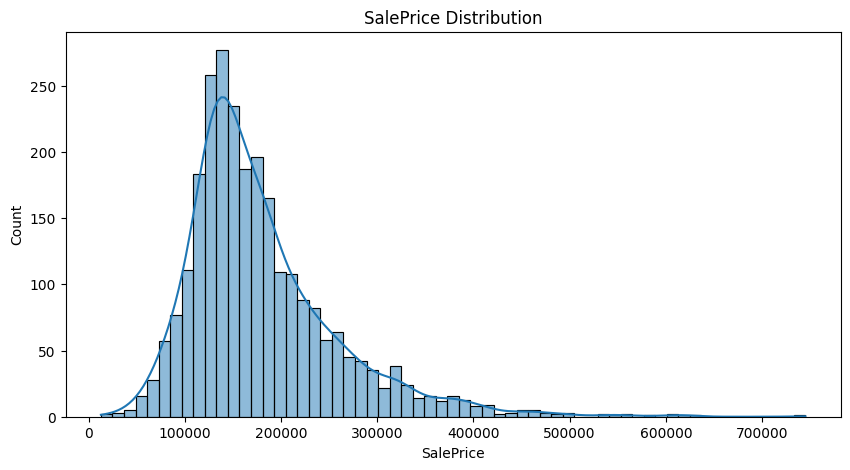

In [ ]:
import matplotlib.pyplot as plt  # ploting mean and median values of sale price in histogram, title, x label sale price, y is count
import seaborn as sns

'''
plt.figure(figsize = (10, 5))
plt.hist(housing['SalePrice'], bins=50, edgecolor='black')
plt.title('SalePrice Distribution')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()
'''

plt.figure(figsize=(10, 5))
sns.histplot(housing['SalePrice'], kde=True)
plt.title('SalePrice Distribution')


print(f"Mean: {housing['SalePrice'].mean():.0f}")
print(f"Median: {housing['SalePrice'].median():0f}")

Plotly graph Histogram and Kernel Density Estimate most houses in the data are between 129,000 and 200 K with some expensive homes on the low part of the right part of the chart.

In [ ]:
import plotly.figure_factory as ff

# Wrap the single SalePrice series in an outer list - that's what the error message
# was hinting at: "make sure your hist_data variable is still a list of lists"
hist_data = [housing['SalePrice'].tolist()]
group_labels = ['SalePrice']
colors = ['#A56CC1']

fig = ff.create_distplot(hist_data, group_labels, colors=colors,
                         bin_size=10000, show_rug=False)
fig.update_layout(title_text='SalePrice Distribution (Histogram + KDE)')
fig.show()

Predictiors Qverall Quality shows somewhat of a normal distrubition, Gr Liv Area, Total Bsmt SF, and 1st Flr SF all show
positive skew and no garage and no basement indicate the na handling, distribution is not indictive of strong predictor on home values.

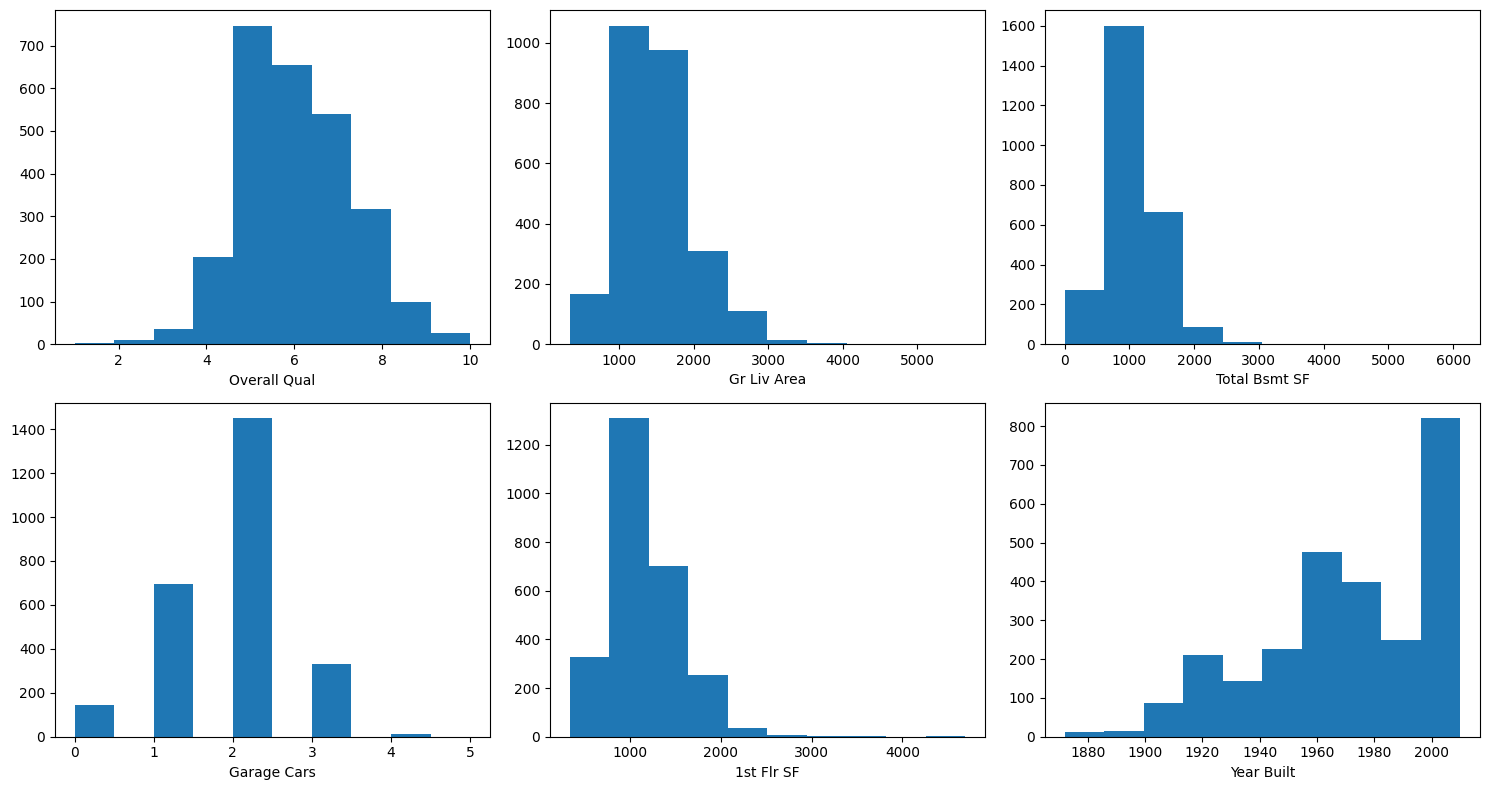

In [ ]:
key_cols = ['Overall Qual', 'Gr Liv Area', 'Total Bsmt SF',
            'Garage Cars', '1st Flr SF', 'Year Built']
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs_flat = axs.flatten()
for n, col in enumerate(key_cols):
    axs_flat[n].hist(housing[col].dropna())
    axs_flat[n].set_xlabel(col)
plt.tight_layout()


Correlations with SalesPrice will help us determine the strongest linear relationship to SalesPrice with features:  OveralQuality, Gr Living Area, Garage Cars at this point have higher values in the correlation.

In [ ]:
numeric_housing = housing.select_dtypes(include=['float64', 'int64'])

correlations = numeric_housing.corr()['SalePrice'].sort_values(ascending=False)
correlations.head(15)


,SalePrice
SalePrice,1.000000
Overall Qual,0.805016
Gr Liv Area,0.705482
Garage Cars,0.646874
Garage Area,0.633607
Total Bsmt SF,0.628955
1st Flr SF,0.618247
Year Built,0.562777
Full Bath,0.542386
Year Remod/Add,0.539932


Identify predictor pairs to drop in regularization. Looking for values between .80 and 1.0 - will change to .70 following this code block to see what other pairs output.

In [ ]:
corr_matrix = numeric_housing.corr().abs()

high_corr = corr_matrix.where(
    (corr_matrix > 0.8) & (corr_matrix < 1.0)
).stack().sort_values(ascending=False)
print(high_corr.head(20))


Garage Area    Garage Cars      0.892247
Garage Cars    Garage Area      0.892247
TotRms AbvGrd  Gr Liv Area      0.807065
Gr Liv Area    TotRms AbvGrd    0.807065
Overall Qual   SalePrice        0.805016
SalePrice      Overall Qual     0.805016
dtype: float64

In [ ]:
corr_matrix = numeric_housing.corr().abs()

high_corr = corr_matrix.where(
    (corr_matrix > 0.7) & (corr_matrix < 1.0)
).stack().sort_values(ascending=False)
print(high_corr.head(20))

Garage Cars    Garage Area      0.892247
Garage Area    Garage Cars      0.892247
Gr Liv Area    TotRms AbvGrd    0.807065
TotRms AbvGrd  Gr Liv Area      0.807065
SalePrice      Overall Qual     0.805016
Overall Qual   SalePrice        0.805016
Total Bsmt SF  1st Flr SF       0.782376
1st Flr SF     Total Bsmt SF    0.782376
Gr Liv Area    SalePrice        0.705482
SalePrice      Gr Liv Area      0.705482
dtype: float64

Checking SalePrice by neighborhood which may show that where you buy matters in house prices.

In [ ]:
housing.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

,SalePrice
Neighborhood,
NoRidge,323610.123077
StoneBr,319553.102041
NridgHt,318903.706667
GrnHill,280000.000000
Veenker,248314.583333
Timber,242343.967742
Somerst,230250.813665
Crawfor,211013.010526
ClearCr,209080.307692


# Processing the Data

Utilizing the data_dict to remove LabelEncoders alphabetizing, In this code block we are focusing on Ordinal data which is highlighted in the data_dict as yellow.  

In [ ]:
# Call every value that is ordinal
ordinal_cols = data_dict[data_dict['Type'] == 'Ordinal'][ 'Variable'].tolist()
print(f'{len(ordinal_cols)} ordinal columns to encode')
print(ordinal_cols)

# Changing quality ratings from str to 1 thru 5 scale: 1 being PO and 5 being EX. Zero means no rating
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond',
                'Heating QC', 'Kitchen Qual', 'Fireplace Qu',
                'Garage Qual', 'Garage Cond', 'Pool QC']
for col in quality_cols:
    housing[col] = housing[col].replace(quality_map)

# Other ordinal columns have their own specific scales - check the data dictionary
bsmt_exp_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
housing['Bsmt Exposure'] = housing['Bsmt Exposure'].replace(bsmt_exp_map)


23 ordinal columns to encode

[
    'Lot Shape',
    'Utilities',
    'Land Slope',
    'Overall Qual',
    'Overall Cond',
    'Exter Qual',
    'Exter Cond',
    'Bsmt Qual',
    'Bsmt Cond',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin Type 2',
    'Heating QC',
    'Electrical',
    'Kitchen Qual',
    'Functional',
    'Fireplace Qu',
    'Garage Finish',
    'Garage Qual',
    'Garage Cond',
    'Paved Drive',
    'Pool QC',
    'Fence'
]

/tmp/ipykernel_2065/2261146267.py:12: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_2065/2261146267.py:16: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Check if encoding worked


In [ ]:
# Step 10b — Remaining ordinal maps (Lot Shape, Utilities, Land Slope, etc.)
lot_shape_map     = {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0}
utilities_map     = {'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0}
land_slope_map    = {'Gtl': 2, 'Mod': 1, 'Sev': 0}
bsmtfin_type_map  = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
electrical_map    = {'FuseP': 0, 'FuseF': 1, 'FuseA': 2, 'Mix': 3, 'SBrkr': 4}
functional_map    = {'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}
garage_finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
paved_drive_map   = {'N': 0, 'P': 1, 'Y': 2}
fence_map         = {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}

housing['Lot Shape']      = housing['Lot Shape'].replace(lot_shape_map).astype(int)
housing['Utilities']      = housing['Utilities'].replace(utilities_map).astype(int)
housing['Land Slope']     = housing['Land Slope'].replace(land_slope_map).astype(int)
housing['BsmtFin Type 1'] = housing['BsmtFin Type 1'].replace(bsmtfin_type_map).astype(int)
housing['BsmtFin Type 2'] = housing['BsmtFin Type 2'].replace(bsmtfin_type_map).astype(int)
housing['Electrical']     = housing['Electrical'].replace(electrical_map).astype(int)
housing['Functional']     = housing['Functional'].replace(functional_map).astype(int)
housing['Garage Finish']  = housing['Garage Finish'].replace(garage_finish_map).astype(int)
housing['Paved Drive']    = housing['Paved Drive'].replace(paved_drive_map).astype(int)
housing['Fence']          = housing['Fence'].replace(fence_map).astype(int)

# Verify
remaining_text = housing[['Lot Shape', 'Utilities', 'Land Slope', 'BsmtFin Type 1',
                          'BsmtFin Type 2', 'Electrical', 'Functional',
                          'Garage Finish', 'Paved Drive', 'Fence']].dtypes
print(remaining_text)

/tmp/ipykernel_2065/1883707722.py:12: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_2065/1883707722.py:13: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_2065/1883707722.py:14: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_2065/1883707722.py:15: FutureWarning:

Lot Shape         int64
Utilities         int64
Land Slope        int64
BsmtFin Type 1    int64
BsmtFin Type 2    int64
Electrical        int64
Functional        int64
Garage Finish     int64
Paved Drive       int64
Fence             int64
dtype: object

In [ ]:
housing[['Exter Qual', 'Bsmt Qual', 'Kitchen Qual', 'Bsmt Exposure']].head(10)

,Exter Qual,Bsmt Qual,Kitchen Qual,Bsmt Exposure
0,3,3,3,1
1,3,0,3,0
2,3,3,4,1
3,4,4,4,1
4,4,4,4,1
5,3,3,3,1
6,4,4,4,3
7,3,4,3,2
8,4,4,4,1
9,3,3,4,2


Encoding nominal columns.  Column count increased below because the nominal encoding drops the column header and treats each unique value in that column as a new feature, this produces expansion in the dataset. We are trying to reduce collinearity in the data set, so drop_first = True to avoid collinearity.

pd.get_dummies is translating string features into binary numbers 1, 0 because the regression model is not capable of determining what 'Foundation' means, the ML is trained on numeric computation.   
Initial column value 81, this value 224.   





---



In [ ]:
# Get every nominal column from the data dictionary, except PID (it's just an ID)
nominal_cols = data_dict[data_dict['Type'] == 'Nominal']['Variable'].tolist()
nominal_cols = [c for c in nominal_cols if c != 'PID']
print(f"{len(nominal_cols)} nominal columns to one-hot encode:")
print(nominal_cols)

housing_encoded = pd.get_dummies(
    housing, columns=nominal_cols, drop_first=True, dtype=int
)
housing_encoded.shape


23 nominal columns to one-hot encode:

[
    'MS SubClass',
    'MS Zoning',
    'Street',
    'Alley',
    'Land Contour',
    'Lot Config',
    'Neighborhood',
    'Condition 1',
    'Condition 2',
    'Bldg Type',
    'House Style',
    'Roof Style',
    'Roof Matl',
    'Exterior 1st',
    'Exterior 2nd',
    'Mas Vnr Type',
    'Foundation',
    'Heating',
    'Central Air',
    'Garage Type',
    'Misc Feature',
    'Sale Type',
    'Sale Condition'
]

(2637, 224)

# Push to Huggingface

## Convert CSV to parquet


In [ ]:
parquet_file = "housing.parquet"
parquet_file


'housing.parquet'

In [ ]:
housing_encoded.to_parquet( parquet_file, index=False)

In [ ]:
!ls -l --si {parquet_file}


-rw-r--r-- 1 root root 313k Jul  1 15:25 housing.parquet


## Verify that pandas can query the local parquet file


In [ ]:
df2 = pd.read_parquet( parquet_file )
df2.shape


(2637, 224)

## Authenticate to Hugging Face


In [ ]:
# Retrieve the token from Colab's secret manager
os.environ["HF_TOKEN"] = userdata.get('hf_token')
_ = os.environ["HF_TOKEN"]
f"{_[:5]} ... {_[-3:]}"

'hf_CR ... Bnq'

In [ ]:
os.environ["HF_ACCOUNT"] = userdata.get('hf_account')
hf_account = os.environ["HF_ACCOUNT"]
hf_account


'RaayGunz'

In [ ]:
hf_repo = "Data_Science-21"
os.environ["HF_REPO"] = hf_repo
hf_repo


'Data_Science-21'

In [ ]:
# Log in automatically without an interactive prompt
!hf auth login --token $HF_TOKEN


Hint: A new version of huggingface_hub (1.21.0) is available! You are using version 1.20.1.
To update, run: hf update
The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `Colab` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Push to Hugging Face


In [ ]:
%%capture hf_upload
%%bash

hf upload \
  --type dataset \
  ${HF_ACCOUNT}/${HF_REPO} \
  housing.parquet


In [ ]:
print(hf_upload.stdout)


[32m✓ Uploaded[0m
  url: https://huggingface.co/datasets/RaayGunz/Data_Science-21/commit/ede7fd4def119a825d2707149291dfcd2df1d243

## Read parquet from Hugging Face


In [ ]:
# Construct the base Hugging Face URL for your dataset files
hf_url = f"https://huggingface.co/datasets/{hf_account}/{hf_repo}/resolve/main/housing.parquet"
hf_url


'https://huggingface.co/datasets/RaayGunz/Data_Science-21/resolve/main/housing.parquet'

In [ ]:
df3 = pd.read_parquet( hf_url )
df3.shape


(2637, 224)

In [ ]:
df3.iloc[:,:5].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PID           2637 non-null   int64  
 1   Lot Frontage  2637 non-null   float64
 2   Lot Area      2637 non-null   int64  
 3   Lot Shape     2637 non-null   int64  
 4   Utilities     2637 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 103.1 KB


In [ ]:
df3.columns.sort_values().to_list()

['1st Flr SF',
 '2nd Flr SF',
 '3Ssn Porch',
 'Alley_None',
 'Alley_Pave',
 'Bedroom AbvGr',
 'Bldg Type_2fmCon',
 'Bldg Type_Duplex',
 'Bldg Type_Twnhs',
 'Bldg Type_TwnhsE',
 'Bsmt Cond',
 'Bsmt Exposure',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Bsmt Qual',
 'Bsmt Unf SF',
 'BsmtFin SF 1',
 'BsmtFin SF 2',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Central Air_Y',
 'Condition 1_Feedr',
 'Condition 1_Norm',
 'Condition 1_PosA',
 'Condition 1_PosN',
 'Condition 1_RRAe',
 'Condition 1_RRAn',
 'Condition 1_RRNe',
 'Condition 1_RRNn',
 'Condition 2_Feedr',
 'Condition 2_Norm',
 'Condition 2_PosA',
 'Condition 2_PosN',
 'Condition 2_RRAe',
 'Condition 2_RRAn',
 'Condition 2_RRNn',
 'Electrical',
 'Enclosed Porch',
 'Exter Cond',
 'Exter Qual',
 'Exterior 1st_AsphShn',
 'Exterior 1st_BrkComm',
 'Exterior 1st_BrkFace',
 'Exterior 1st_CBlock',
 'Exterior 1st_CemntBd',
 'Exterior 1st_HdBoard',
 'Exterior 1st_ImStucc',
 'Exterior 1st_MetalSd',
 'Exterior 1st_Plywood',
 'Exterior 1st_PreCast',
 'Ex